# ==============================
# Model Training
# ==============================

In [4]:
!pip install xgboost

In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

from xgboost import XGBRegressor

# load feature engineered datase

In [6]:
df = pd.read_csv('../outputs/predictions/staten_island_otp_features.csv')

df.head()

,Month,Day Time,Delayed Trains,On-Time Trips,On-Time Performance,Delayed Trains (With Boat),On-Time Trips (With Boat),On-Time Performance (With Boat),Scheduled Trips,Incomplete Trips,...,OTP_Lag_1,OTP_Lag_2,OTP_Lag_3,Delayed_Trains_Lag_1,Scheduled_Trips_Lag_1,OTP_Rolling_3,OTP_Rolling_6,Delayed_Trains_Rolling_3,Delay_Rate,Next_Month_OTP
0,2006-07-01,7-Day,104,3362,0.970,192,3274,0.945,3466,26.0,...,0.983,0.968,0.965,61.0,3490.0,0.972000,0.974833,97.666667,0.030006,0.971
1,2006-08-01,7-Day,105,3506,0.971,160,3451,0.956,3611,0.0,...,0.970,0.983,0.968,104.0,3466.0,0.973667,0.978333,92.666667,0.029078,0.953
2,2006-09-01,7-Day,159,3228,0.953,220,3167,0.935,3387,0.0,...,0.971,0.970,0.983,105.0,3611.0,0.974667,0.976167,90.000000,0.046944,0.955
3,2006-10-01,7-Day,159,3401,0.955,220,3340,0.938,3560,38.0,...,0.953,0.971,0.970,159.0,3387.0,0.964667,0.968333,122.666667,0.044663,0.930
4,2006-11-01,7-Day,239,3197,0.930,303,3133,0.912,3436,20.0,...,0.955,0.953,0.971,159.0,3560.0,0.959667,0.966667,141.000000,0.069558,0.980


# ML Input

In [7]:
features = [
    'Delayed Trains',
    'On-Time Trips',
    'Scheduled Trips',
    'OTP_Lag_1',
    'OTP_Lag_2',
    'OTP_Lag_3',
    'OTP_Rolling_3',
    'OTP_Rolling_6',
    'Delayed_Trains_Lag_1',
    'Delayed_Trains_Rolling_3',
    'Delay_Rate',
    'Year',
    'Month_Number',
    'Quarter'
]

In [8]:
target = 'Next_Month_OTP'

In [9]:
df = pd.get_dummies(
    df,
    columns=['Day Time', 'Season'],
    drop_first=True
)

In [10]:
encoded_cols = [
    col for col in df.columns
    if 'Day Time_' in col or 'Season_' in col
]

features.extend(encoded_cols)

Define x,Y

In [11]:
X = df[features]
y = df[target]

In [12]:
X.head()

,Delayed Trains,On-Time Trips,Scheduled Trips,OTP_Lag_1,OTP_Lag_2,OTP_Lag_3,OTP_Rolling_3,OTP_Rolling_6,Delayed_Trains_Lag_1,Delayed_Trains_Rolling_3,...,Year,Month_Number,Quarter,Day Time_AM Rush,Day Time_PM Rush,Day Time_Weekday,Day Time_Weekend,Season_Spring,Season_Summer,Season_Winter
0,104,3362,3466,0.983,0.968,0.965,0.972000,0.974833,61.0,97.666667,...,2006,7,3,False,False,False,False,False,True,False
1,105,3506,3611,0.970,0.983,0.968,0.973667,0.978333,104.0,92.666667,...,2006,8,3,False,False,False,False,False,True,False
2,159,3228,3387,0.971,0.970,0.983,0.974667,0.976167,105.0,90.000000,...,2006,9,3,False,False,False,False,False,False,False
3,159,3401,3560,0.953,0.971,0.970,0.964667,0.968333,159.0,122.666667,...,2006,10,4,False,False,False,False,False,False,False
4,239,3197,3436,0.955,0.953,0.971,0.959667,0.966667,159.0,141.000000,...,2006,11,4,False,False,False,False,False,False,False


# Train Test Split

In [13]:
split_index = int(len(df) * 0.8)

X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]

# Baseline model Linear Regression

In [14]:
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

lr_preds = lr_model.predict(X_test)

In [15]:
print("Linear Regression Results")
print("MAE:", mean_absolute_error(y_test, lr_preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lr_preds)))
print("R2:", r2_score(y_test, lr_preds))

Linear Regression Results
MAE: 0.030509457529501738
RMSE: 0.048734374371494825
R2: 0.11924026872371962


# Random Forest

In [16]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)

In [17]:
print("Random Forest Results")
print("MAE:", mean_absolute_error(y_test, rf_preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_preds)))
print("R2:", r2_score(y_test, rf_preds))

Random Forest Results
MAE: 0.03106185897435893
RMSE: 0.04761216314760355
R2: 0.1593359299255428


# xgboost model

In [18]:
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_preds = xgb_model.predict(X_test)

In [19]:
print("XGBoost Results")
print("MAE:", mean_absolute_error(y_test, xgb_preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test, xgb_preds)))
print("R2:", r2_score(y_test, xgb_preds))

XGBoost Results
MAE: 0.0319288876301203
RMSE: 0.04720821137382304
R2: 0.1735401648265925


# Comparing Models

In [20]:
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest',
        'XGBoost'
    ],
    'MAE': [
        mean_absolute_error(y_test, lr_preds),
        mean_absolute_error(y_test, rf_preds),
        mean_absolute_error(y_test, xgb_preds)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, lr_preds)),
        np.sqrt(mean_squared_error(y_test, rf_preds)),
        np.sqrt(mean_squared_error(y_test, xgb_preds))
    ],
    'R2': [
        r2_score(y_test, lr_preds),
        r2_score(y_test, rf_preds),
        r2_score(y_test, xgb_preds)
    ]
})

results

,Model,MAE,RMSE,R2
0,Linear Regression,0.030509,0.048734,0.119240
1,Random Forest,0.031062,0.047612,0.159336
2,XGBoost,0.031929,0.047208,0.173540


# Actual vs Predicted Plot

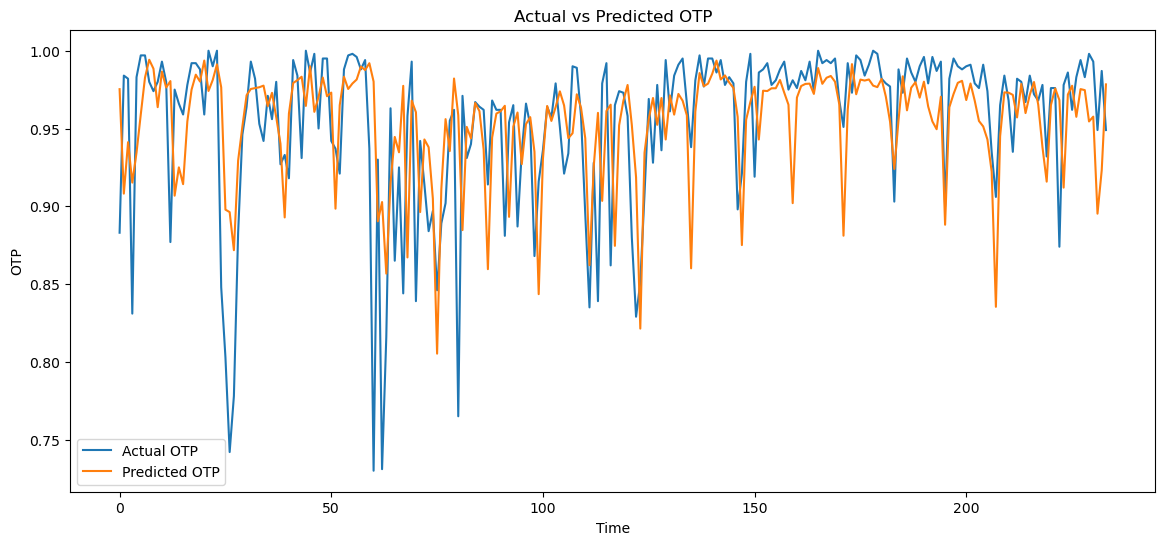

In [21]:
plt.figure(figsize=(14,6))

plt.plot(
    y_test.values,
    label='Actual OTP'
)

plt.plot(
    xgb_preds,
    label='Predicted OTP'
)

plt.title('Actual vs Predicted OTP')
plt.xlabel('Time')
plt.ylabel('OTP')

plt.legend()

plt.show()

In [22]:
import joblib

In [23]:
joblib.dump(
    xgb_model,
    '../models/xgboost_otp_model.pkl'
)

['../models/xgboost_otp_model.pkl']